# Eksperimen Bonus 1 RMSNorm

Membandingkan performa model **tanpa normalisasi** vs **dengan RMSNorm** pada dataset yang sama.

Aspek yang dibandingkan:
1. Hasil akhir prediksi (akurasi)
2. Grafik training loss dan validation loss tiap epoch setelah pelatihan
3. Distribusi bobot dan gradien bobot

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import sys, os

sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))
import ffnn
# importlib.reload(ffnn)

%matplotlib inline

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

## 1. Data Loading & Preprocessing

In [28]:
# Load dataset
df = pd.read_csv("../data/dataset.csv")
print(f"Dataset shape: {df.shape}")
print(f"Target distribution:\n{df['placement_status'].value_counts()}")
df.head()

Dataset shape: (10000, 12)
Target distribution:
placement_status
Placed        6153
Not Placed    3847
Name: count, dtype: int64


,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed


In [29]:
# Encode categorical features
label_encoders = {}
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'placement_status' in categorical_cols:
    categorical_cols.remove('placement_status')

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Encode target
target_le = LabelEncoder()
df['placement_status'] = target_le.fit_transform(df['placement_status'])

# Separate features and target
X = df.drop('placement_status', axis=1).values
y = df['placement_status'].values

num_classes = len(np.unique(y))
num_features = X.shape[1]
print(f"Number of features: {num_features}")
print(f"Number of classes: {num_classes}")
print(f"Classes: {target_le.classes_}")

# Split into train, validation, test (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print(f"\nTrain: {X_train.shape[0]} samples")
print(f"Val:   {X_val.shape[0]} samples")
print(f"Test:  {X_test.shape[0]} samples")

Number of features: 11
Number of classes: 2
Classes: ['Not Placed' 'Placed']

Train: 7000 samples
Val:   1500 samples
Test:  1500 samples


In [30]:
# Hyperparameters
EPOCHS = 50
LR = 0.01
BATCH_SIZE = 32
LAMBDA = 0.001
SEED = 42

print(f"Epochs: {EPOCHS}, LR: {LR}, Batch Size: {BATCH_SIZE}, Lambda: {LAMBDA}")

Epochs: 50, LR: 0.01, Batch Size: 32, Lambda: 0.001


## 2. Definisi Model untuk Eksperimen RMSNorm

In [31]:
def create_model_no_norm(num_features, num_classes, seed=42):
    """Model TANPA RMSNorm"""
    np.random.seed(seed)
    model = ffnn.Model(
        layers=[
            ffnn.Linear(num_features, 64), # Layer 0
            ffnn.Relu(), # Layer 1
            ffnn.Linear(64, 32), # Layer 2
            ffnn.Relu(), # Layer 3
            ffnn.Linear(32, num_classes), # Layer 4
            ffnn.Softmax(), # Layer 5
        ],
        loss=ffnn.CrossEntropyLoss(),
    )
    return model


def create_model_with_norm(num_features, num_classes, seed=42):
    """Model DENGAN RMSNorm"""
    np.random.seed(seed)
    model = ffnn.Model(
        layers=[
            ffnn.RMSNorm(num_features),# Norm sebelum layer pertama
            ffnn.Linear(num_features, 64),    # Layer 1
            ffnn.RMSNorm(64), # Norm setelah Linear
            ffnn.Relu(), # Layer 3
            ffnn.Linear(64, 32), # Layer 4
            ffnn.RMSNorm(32), # Norm setelah Linear
            ffnn.Relu(), # Layer 6
            ffnn.Linear(32, num_classes), # Layer 7
            ffnn.Softmax(), # Layer 8
        ],
        loss=ffnn.CrossEntropyLoss(),
    )
    return model


print("Model Tanpa Norm: Linear(in, 64) -> ReLU -> Linear(64, 32) -> ReLU -> Linear(32, out) -> Softmax")
print("Model Dengan Norm: RMSNorm -> Linear(in, 64) -> RMSNorm -> ReLU -> Linear(64, 32) -> RMSNorm -> ReLU -> Linear(32, out) -> Softmax")

Model Tanpa Norm: Linear(in, 64) -> ReLU -> Linear(64, 32) -> ReLU -> Linear(32, out) -> Softmax
Model Dengan Norm: RMSNorm -> Linear(in, 64) -> RMSNorm -> ReLU -> Linear(64, 32) -> RMSNorm -> ReLU -> Linear(32, out) -> Softmax


## 3. Menjalankan Eksperimen RMSNorm

### 3.1 Tanpa Normalisasi

In [32]:
model_no_norm = create_model_no_norm(num_features, num_classes, seed=SEED)
history_no_norm = model_no_norm.fit(
    X_train, y_train,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR,
    penalty="l2", lambda_=LAMBDA,
    verbose=1, seed=SEED,
    validation_data=(X_val, y_val)
)

Epoch 1/50 [==============================] - train_loss: 0.686107 - val_loss: 0.686059
Epoch 2/50 [==============================] - train_loss: 0.647645 - val_loss: 0.648952
Epoch 3/50 [==============================] - train_loss: 0.621978 - val_loss: 0.624127
Epoch 4/50 [==============================] - train_loss: 0.604790 - val_loss: 0.607826
Epoch 5/50 [==============================] - train_loss: 0.593696 - val_loss: 0.598054
Epoch 6/50 [==============================] - train_loss: 0.586595 - val_loss: 0.592056
Epoch 7/50 [==============================] - train_loss: 0.581667 - val_loss: 0.588214
Epoch 8/50 [==============================] - train_loss: 0.578067 - val_loss: 0.585592
Epoch 9/50 [==============================] - train_loss: 0.575421 - val_loss: 0.583832
Epoch 10/50 [==============================] - train_loss: 0.573214 - val_loss: 0.582283
Epoch 11/50 [==============================] - train_loss: 0.571399 - val_loss: 0.581120
Epoch 12/50 [=================

### 3.2 Dengan RMSNorm

In [33]:
model_with_norm = create_model_with_norm(num_features, num_classes, seed=SEED)
history_with_norm = model_with_norm.fit(
    X_train, y_train,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR,
    penalty="l2", lambda_=LAMBDA,
    verbose=1, seed=SEED,
    validation_data=(X_val, y_val)
)

Epoch 1/50 [..............................] 2/219

Epoch 1/50 [==============================] - train_loss: 0.658387 - val_loss: 0.655604
Epoch 2/50 [==============================] - train_loss: 0.614699 - val_loss: 0.615874
Epoch 3/50 [==============================] - train_loss: 0.601231 - val_loss: 0.605141
Epoch 4/50 [==============================] - train_loss: 0.593734 - val_loss: 0.599953
Epoch 5/50 [==============================] - train_loss: 0.588669 - val_loss: 0.597041
Epoch 6/50 [==============================] - train_loss: 0.584086 - val_loss: 0.593720
Epoch 7/50 [==============================] - train_loss: 0.580493 - val_loss: 0.591652
Epoch 8/50 [==============================] - train_loss: 0.577164 - val_loss: 0.589299
Epoch 9/50 [==============================] - train_loss: 0.574163 - val_loss: 0.587279
Epoch 10/50 [==============================] - train_loss: 0.571461 - val_loss: 0.585089
Epoch 11/50 [==============================] - train_loss: 0.569194 - val_loss: 0.583835
Epoch 12/50 [=================

## 4. Perbandingan Hasil Prediksi (RMSNorm)

In [34]:
from sklearn.metrics import f1_score


preds_no_norm = model_no_norm.predict(X_test)
preds_with_norm = model_with_norm.predict(X_test)

acc_no_norm = accuracy_score(y_test, preds_no_norm)
acc_with_norm = accuracy_score(y_test, preds_with_norm)

f1_no_norm = f1_score(y_test, preds_no_norm)
f1_with_norm = f1_score(y_test, preds_with_norm)

print("Perbandingan Hasil prediksi")
print(f"{'Model':<25} {'Accuracy':>10} {'F1 Score':>10}")
print(f"{'Tanpa Normalisasi':<23} {acc_no_norm:>10.4f} {f1_no_norm:>10.4f}")
print(f"{'Dengan RMSNorm':<23} {acc_with_norm:>10.4f} {f1_with_norm:>10.4f}")
print(f"{'Selisih':<23} {acc_with_norm - acc_no_norm:>+10.4f} {f1_with_norm - f1_no_norm:>+10.4f}")

Perbandingan Hasil prediksi
Model                       Accuracy   F1 Score
Tanpa Normalisasi           0.7640     0.8156
Dengan RMSNorm              0.7567     0.8104
Selisih                    -0.0073    -0.0052


In [35]:
for name, preds in [("Tanpa Normalisasi", preds_no_norm), ("Dengan RMSNorm", preds_with_norm)]:
    print(f"Classification Report - {name}")
    print(classification_report(y_test, preds, target_names=target_le.classes_))

Classification Report - Tanpa Normalisasi
              precision    recall  f1-score   support

  Not Placed       0.72      0.63      0.67       577
      Placed       0.79      0.85      0.82       923

    accuracy                           0.76      1500
   macro avg       0.75      0.74      0.74      1500
weighted avg       0.76      0.76      0.76      1500

Classification Report - Dengan RMSNorm
              precision    recall  f1-score   support

  Not Placed       0.71      0.62      0.66       577
      Placed       0.78      0.85      0.81       923

    accuracy                           0.76      1500
   macro avg       0.75      0.73      0.74      1500
weighted avg       0.75      0.76      0.75      1500



In [36]:
print("\nSample Predictions (first 20 test samples):")
print(f"{'Actual':<10} {'No Norm':<10} {'RMSNorm':<10}")
print("-" * 30)
for i in range(min(20, len(y_test))):
    print(f"{y_test[i]:<10} {preds_no_norm[i]:<10} {preds_with_norm[i]:<10}")


Sample Predictions (first 20 test samples):
Actual     No Norm    RMSNorm   
------------------------------
1          1          1         
1          1          1         
1          1          1         
1          1          1         
1          0          0         
1          1          1         
1          1          1         
1          1          1         
1          1          1         
0          1          0         
1          1          1         
0          0          0         
1          1          1         
1          1          1         
1          1          1         
0          1          1         
1          0          0         
1          0          0         
1          1          1         
0          0          0         


## 5. Grafik Training Loss & Validation Loss (RMSNorm)

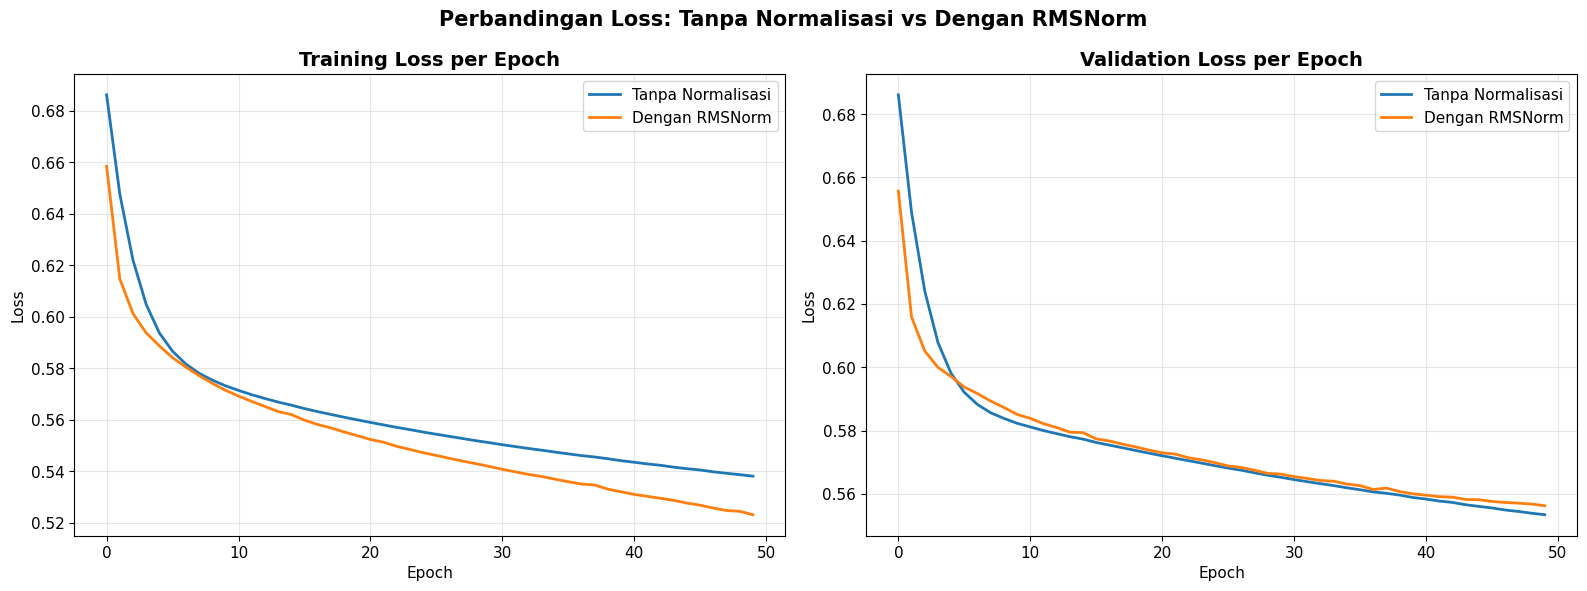

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Training Loss
ax = axes[0]
ax.plot(history_no_norm["train_loss"], label="Tanpa Normalisasi", linewidth=2)
ax.plot(history_with_norm["train_loss"], label="Dengan RMSNorm", linewidth=2)
ax.set_title("Training Loss per Epoch", fontsize=14, fontweight='bold')
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True, alpha=0.3)

# Validation Loss
ax = axes[1]
ax.plot(history_no_norm["val_loss"], label="Tanpa Normalisasi", linewidth=2)
ax.plot(history_with_norm["val_loss"], label="Dengan RMSNorm", linewidth=2)
ax.set_title("Validation Loss per Epoch", fontsize=14, fontweight='bold')
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True, alpha=0.3)

fig.suptitle("Perbandingan Loss: Tanpa Normalisasi vs Dengan RMSNorm", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Distribusi Bobot & Gradien (RMSNorm)

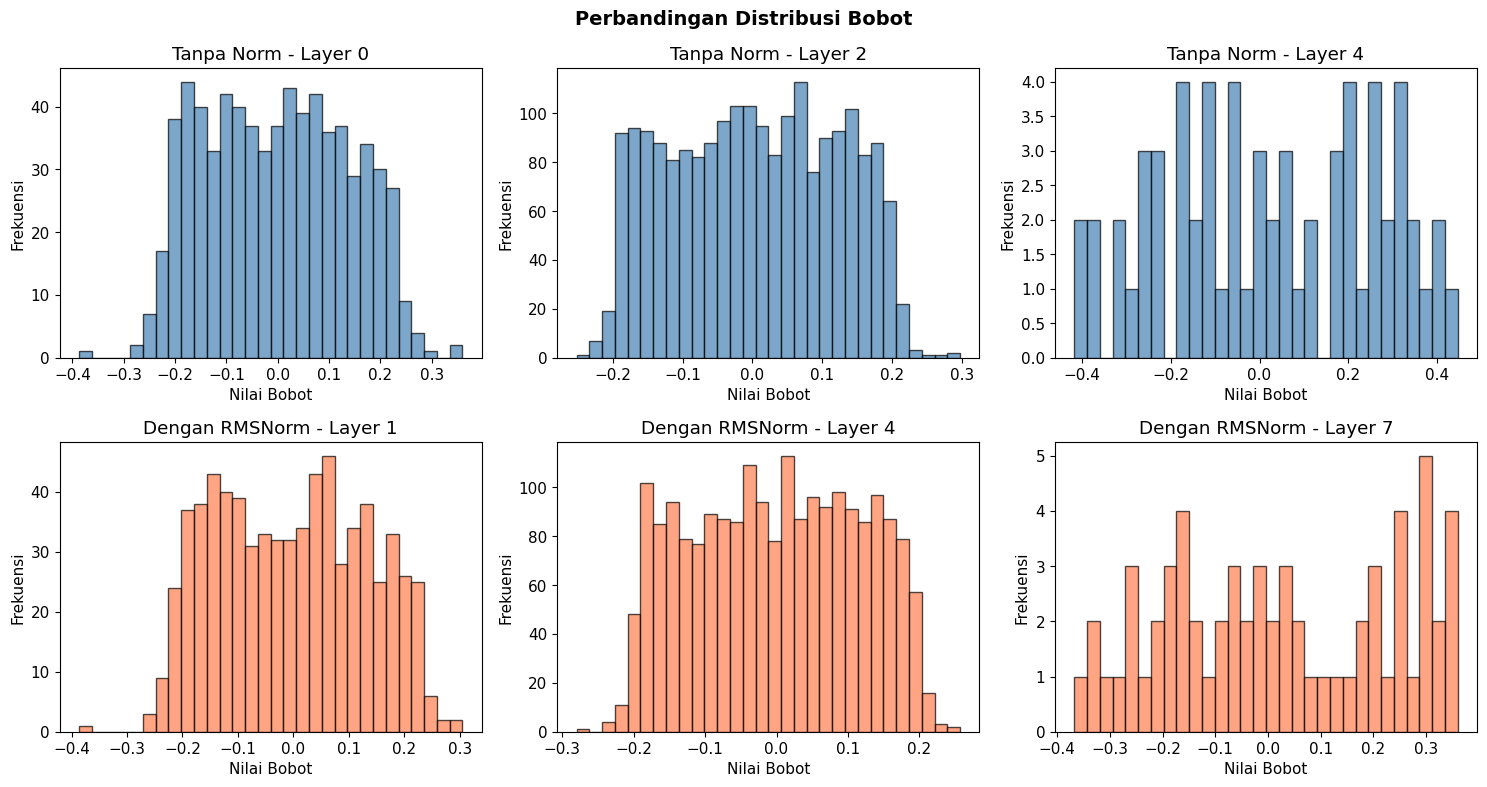

In [38]:
# Indeks layer Linear pada model tanpa normalisasi: 0, 2, 4
# Indeks layer Linear pada model dengan normalisasi: 1, 4, 7

linear_idx_no_norm = [0, 2, 4]
linear_idx_with_norm = [1, 4, 7]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Tanpa Normalisasi — bobot
for i, idx in enumerate(linear_idx_no_norm):
    w = model_no_norm.layers[idx].weights.data.flatten()
    axes[0][i].hist(w, bins=30, edgecolor="black", alpha=0.7, color="steelblue")
    axes[0][i].set_title(f"Tanpa Norm - Layer {idx}")
    axes[0][i].set_xlabel("Nilai Bobot")
    axes[0][i].set_ylabel("Frekuensi")

# Dengan Normalisasi — bobot
for i, idx in enumerate(linear_idx_with_norm):
    w = model_with_norm.layers[idx].weights.data.flatten()
    axes[1][i].hist(w, bins=30, edgecolor="black", alpha=0.7, color="coral")
    axes[1][i].set_title(f"Dengan RMSNorm - Layer {idx}")
    axes[1][i].set_xlabel("Nilai Bobot")
    axes[1][i].set_ylabel("Frekuensi")

fig.suptitle("Perbandingan Distribusi Bobot", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

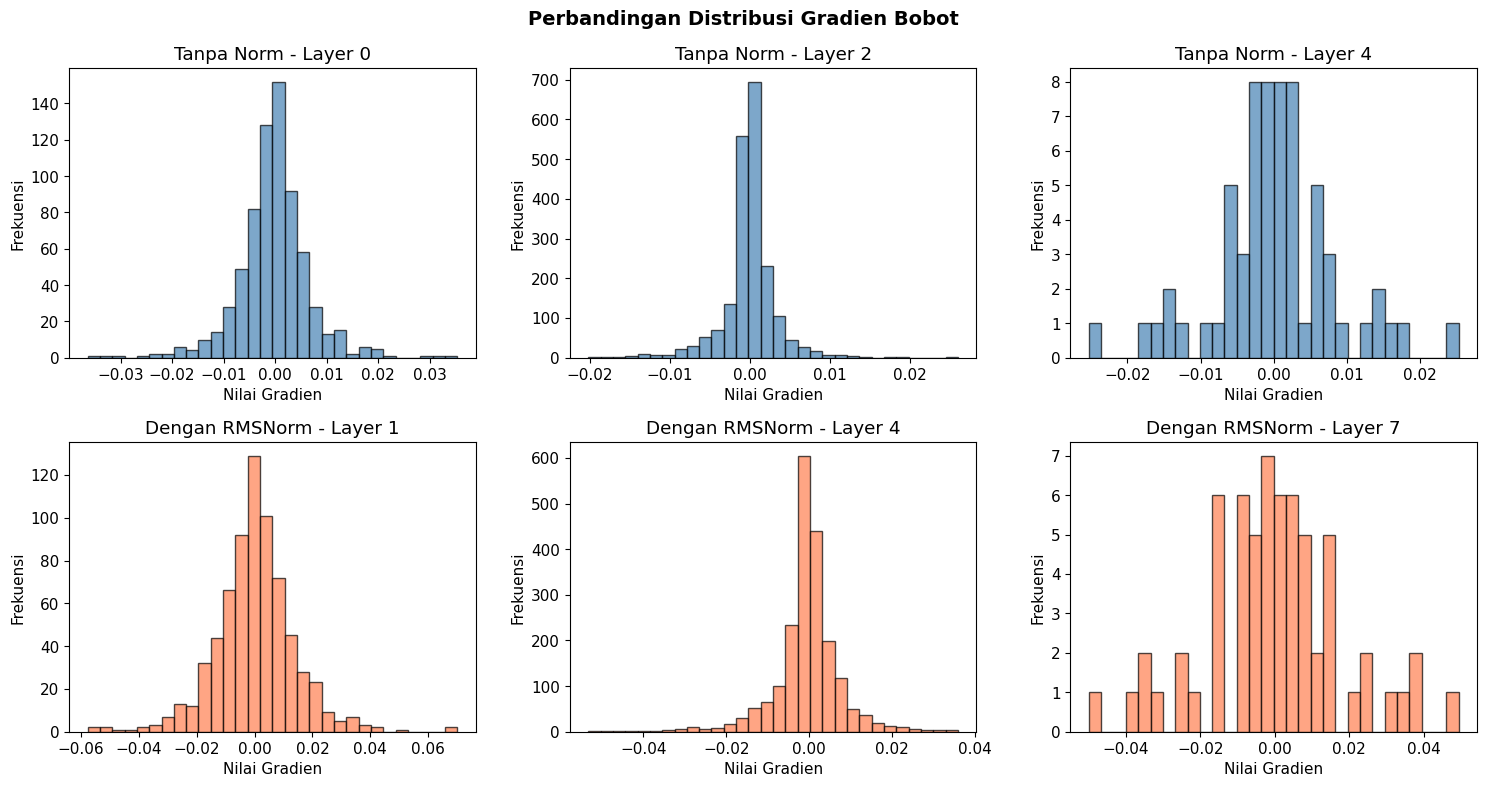

In [39]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Tanpa Normalisasi — gradien
for i, idx in enumerate(linear_idx_no_norm):
    layer = model_no_norm.layers[idx]
    if hasattr(layer, 'dw') and layer.dw is not None:
        g = layer.dw.flatten()
        axes[0][i].hist(g, bins=30, edgecolor="black", alpha=0.7, color="steelblue")
    axes[0][i].set_title(f"Tanpa Norm - Layer {idx}")
    axes[0][i].set_xlabel("Nilai Gradien")
    axes[0][i].set_ylabel("Frekuensi")

# Dengan Normalisasi — gradien
for i, idx in enumerate(linear_idx_with_norm):
    layer = model_with_norm.layers[idx]
    if hasattr(layer, 'dw') and layer.dw is not None:
        g = layer.dw.flatten()
        axes[1][i].hist(g, bins=30, edgecolor="black", alpha=0.7, color="coral")
    axes[1][i].set_title(f"Dengan RMSNorm - Layer {idx}")
    axes[1][i].set_xlabel("Nilai Gradien")
    axes[1][i].set_ylabel("Frekuensi")

fig.suptitle("Perbandingan Distribusi Gradien Bobot", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Analisis RMSNorm

**Hasil:**
- Model dengan RMSNorm menunjukkan konvergensi lebih cepat (loss turun lebih awal)
- Distribusi bobot cenderung lebih seragam dan terkonsentrasi di sekitar 0
- Distribusi gradien lebih stabil dan tidak terlalu spread out
- Akurasi akhir bisa lebih tinggi, terutama pada jaringan yang lebih dalam